# v3 H5 检查测试 Notebook

这个 notebook 用来快速查看 `output_folder_v3` 里的两个 HDF5 文件内容：
- `2019_dataset_dual_V3.h5`
- `2019_dataset_flow_V3.h5`

主要看三件事：文件结构、样本长什么样、图像与光流是否对得上。

In [15]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

project_root = Path.cwd()
v3_dir = project_root / 'output_folder_v3'
dual_h5 = v3_dir / '2019_dataset_dual_V3.h5'
flow_h5 = v3_dir / '2019_dataset_flow_V3.h5'
times_trainval_path = v3_dir / 'times_trainval.npy'
times_test_path = v3_dir / 'times_test.npy'

print('project_root =', project_root)
print('v3_dir =', v3_dir)
print('dual_h5 exists =', dual_h5.exists(), dual_h5)
print('flow_h5 exists =', flow_h5.exists(), flow_h5)
print('times_trainval exists =', times_trainval_path.exists(), times_trainval_path)
print('times_test exists =', times_test_path.exists(), times_test_path)

project_root = e:\造数据集
v3_dir = e:\造数据集\output_folder_v3
dual_h5 exists = True e:\造数据集\output_folder_v3\2019_dataset_dual_V3.h5
flow_h5 exists = True e:\造数据集\output_folder_v3\2019_dataset_flow_V3.h5
times_trainval exists = True e:\造数据集\output_folder_v3\times_trainval.npy
times_test exists = True e:\造数据集\output_folder_v3\times_test.npy


In [16]:
def describe_h5_group(obj, prefix=''):
    if isinstance(obj, h5py.Dataset):
        print(f'{prefix}{obj.name} | shape={obj.shape} | dtype={obj.dtype} | chunks={obj.chunks} | compression={obj.compression}')
        if obj.attrs:
            print(f'{prefix}  attrs={dict(obj.attrs)}')
        return

    print(f'{prefix}{obj.name}/')
    if obj.attrs:
        print(f'{prefix}  attrs={dict(obj.attrs)}')
    for key in obj.keys():
        describe_h5_group(obj[key], prefix + '  ')

print('=== dual h5 结构 ===')
with h5py.File(dual_h5, 'r') as f:
    describe_h5_group(f)

print('\n=== flow h5 结构 ===')
with h5py.File(flow_h5, 'r') as f:
    describe_h5_group(f)

=== dual h5 结构 ===
//
  /trainval/
    /trainval/global_images_log | shape=(101368, 3, 256, 256) | dtype=uint8 | chunks=(100, 3, 256, 256) | compression=lzf
    /trainval/local_images_log | shape=(101368, 3, 128, 128) | dtype=uint8 | chunks=(100, 3, 128, 128) | compression=lzf
    /trainval/pv_log | shape=(101368,) | dtype=float32 | chunks=(100,) | compression=None
    /trainval/sun_pos | shape=(101368, 2) | dtype=int32 | chunks=(100, 2) | compression=None

=== flow h5 结构 ===
//
  /trainval/
    /trainval/global_flow_log | shape=(101368, 2, 256, 256) | dtype=float16 | chunks=(1, 2, 256, 256) | compression=lzf


In [17]:
with h5py.File(dual_h5, 'r') as f:
    grp = f['trainval']
    global_ds = grp['global_images_log']
    local_ds = grp['local_images_log']
    pv_ds = grp['pv_log']
    sun_ds = grp['sun_pos']

    print('trainval length =', len(global_ds))
    print('global_images_log shape/dtype =', global_ds.shape, global_ds.dtype)
    print('local_images_log shape/dtype =', local_ds.shape, local_ds.dtype)
    print('pv_log shape/dtype =', pv_ds.shape, pv_ds.dtype)
    print('sun_pos shape/dtype =', sun_ds.shape, sun_ds.dtype)

    pv_values = pv_ds[:]
    sun_values = sun_ds[:]
    print('pv min/max/mean =', float(np.min(pv_values)), float(np.max(pv_values)), float(np.mean(pv_values)))
    print('sun_pos x range =', int(np.min(sun_values[:, 0])), int(np.max(sun_values[:, 0])))
    print('sun_pos y range =', int(np.min(sun_values[:, 1])), int(np.max(sun_values[:, 1])))

    sample_indices = [0, len(global_ds) // 2, len(global_ds) - 1]
    for idx in sample_indices:
        global_sample = global_ds[idx]
        local_sample = local_ds[idx]
        print(f'idx={idx} | global shape={global_sample.shape} dtype={global_sample.dtype} | local shape={local_sample.shape} dtype={local_sample.dtype} | pv={float(pv_ds[idx]):.4f} | sun_pos={sun_ds[idx].tolist()}')

trainval length = 101368
global_images_log shape/dtype = (101368, 3, 256, 256) uint8
local_images_log shape/dtype = (101368, 3, 128, 128) uint8
pv_log shape/dtype = (101368,) float32
sun_pos shape/dtype = (101368, 2) int32
pv min/max/mean = 0.0006807249737903476 29.58485221862793 15.081403732299805
sun_pos x range = 76 1710
sun_pos y range = 590 1558
idx=0 | global shape=(3, 256, 256) dtype=uint8 | local shape=(3, 128, 128) dtype=uint8 | pv=0.0770 | sun_pos=[129, 1120]
idx=50684 | global shape=(3, 256, 256) dtype=uint8 | local shape=(3, 128, 128) dtype=uint8 | pv=22.6034 | sun_pos=[1063, 1205]
idx=101367 | global shape=(3, 256, 256) dtype=uint8 | local shape=(3, 128, 128) dtype=uint8 | pv=3.4490 | sun_pos=[1710, 1504]


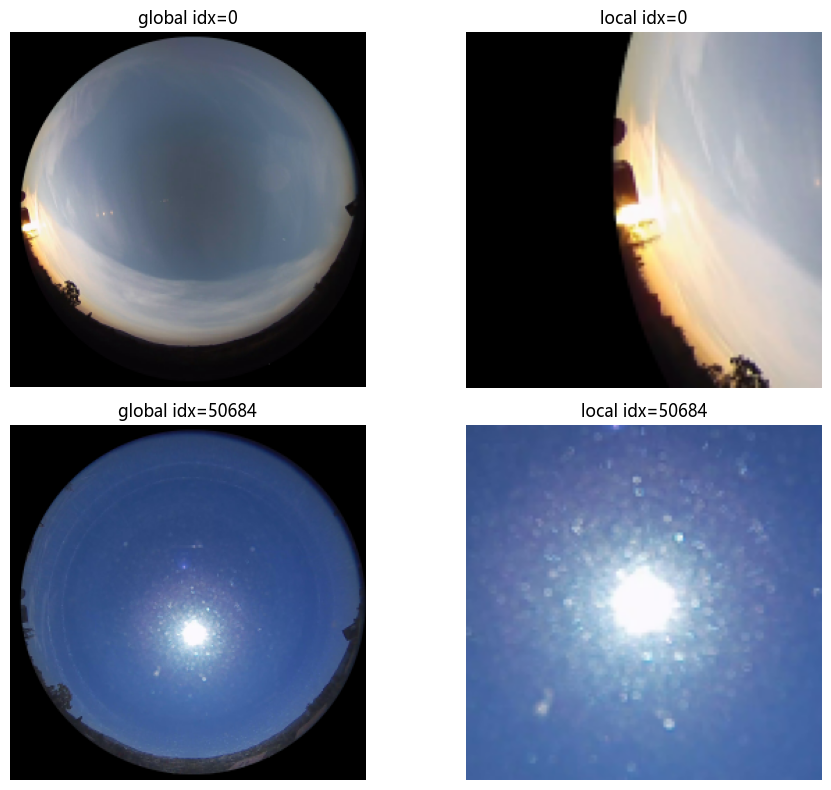

In [18]:
def chw_to_hwc(image):
    return np.transpose(image, (1, 2, 0))

with h5py.File(dual_h5, 'r') as f:
    grp = f['trainval']
    total = len(grp['global_images_log'])
    sample_indices = [0, total // 2]

    fig, axes = plt.subplots(len(sample_indices), 2, figsize=(10, 8))
    if len(sample_indices) == 1:
        axes = np.array([axes])

    for row, idx in enumerate(sample_indices):
        global_img = chw_to_hwc(grp['global_images_log'][idx])
        local_img = chw_to_hwc(grp['local_images_log'][idx])

        axes[row, 0].imshow(global_img)
        axes[row, 0].set_title(f'global idx={idx}')
        axes[row, 0].axis('off')

        axes[row, 1].imshow(local_img)
        axes[row, 1].set_title(f'local idx={idx}')
        axes[row, 1].axis('off')

    plt.tight_layout()
    plt.show()

global_flow_log shape/dtype = (101368, 2, 256, 256) float16
first frame abs sum = 0.0
sample flow min/max/mean = -9.6015625 2.505859375 -0.8204110264778137
sample flow std = 1.510604739189148
sample flow abs min/max = 0.0 9.6015625


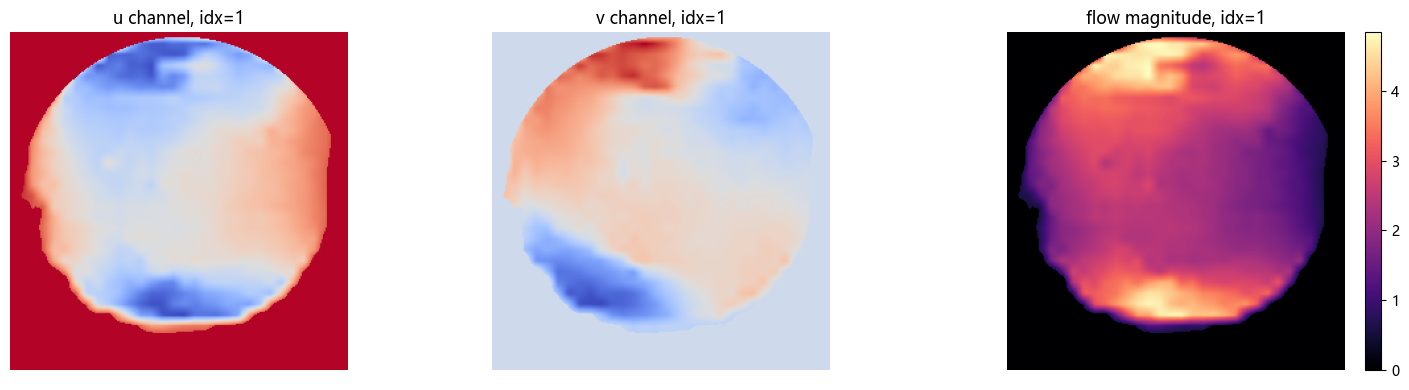

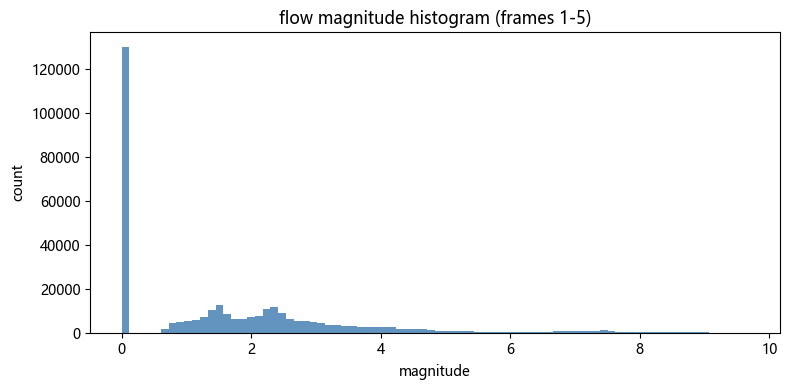

In [19]:
with h5py.File(flow_h5, 'r') as f:
    grp = f['trainval']
    flow_ds = grp['global_flow_log']

    print('global_flow_log shape/dtype =', flow_ds.shape, flow_ds.dtype)
    first_frame = flow_ds[0]
    first_frame_sum = float(np.sum(np.abs(first_frame.astype(np.float32))))
    print('first frame abs sum =', first_frame_sum)

    sample_flow = flow_ds[1:6].astype(np.float32)
    print('sample flow min/max/mean =', float(np.min(sample_flow)), float(np.max(sample_flow)), float(np.mean(sample_flow)))
    print('sample flow std =', float(np.std(sample_flow)))

    abs_all = np.abs(sample_flow)
    print('sample flow abs min/max =', float(np.min(abs_all)), float(np.max(abs_all)))

    magnitude = np.sqrt(sample_flow[0, 0] ** 2 + sample_flow[0, 1] ** 2)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(sample_flow[0, 0], cmap='coolwarm')
    axes[0].set_title('u channel, idx=1')
    axes[0].axis('off')

    axes[1].imshow(sample_flow[0, 1], cmap='coolwarm')
    axes[1].set_title('v channel, idx=1')
    axes[1].axis('off')

    im = axes[2].imshow(magnitude, cmap='magma')
    axes[2].set_title('flow magnitude, idx=1')
    axes[2].axis('off')
    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

    hist_data = np.sqrt(sample_flow[:, 0] ** 2 + sample_flow[:, 1] ** 2).ravel()
    plt.figure(figsize=(8, 4))
    plt.hist(hist_data, bins=80, color='steelblue', alpha=0.85)
    plt.title('flow magnitude histogram (frames 1-5)')
    plt.xlabel('magnitude')
    plt.ylabel('count')
    plt.tight_layout()
    plt.show()

In [20]:
times_trainval = np.load(times_trainval_path, allow_pickle=True)
times_test = np.load(times_test_path, allow_pickle=True)
all_times = np.concatenate([times_trainval, times_test])

print('times_trainval len =', len(times_trainval))
print('times_test len =', len(times_test))
print('all_times len =', len(all_times))
print('all_times first =', all_times[0])
print('all_times last =', all_times[-1])

with h5py.File(dual_h5, 'r') as f:
    frame_count = len(f['trainval']['global_images_log'])
    print('dual h5 frame_count =', frame_count)
    print('time/frame一致 =', frame_count == len(all_times))

if len(all_times) > 1:
    deltas = np.diff(all_times.astype('datetime64[s]').astype('int64'))
    print('time delta min/max =', int(np.min(deltas)), int(np.max(deltas)))
    print('delta > 65s count =', int(np.sum(deltas > 65)))

times_trainval len = 81094
times_test len = 20274
all_times len = 101368
all_times first = 2019-01-24 07:32:30
all_times last = 2019-10-26 17:30:20
dual h5 frame_count = 101368
time/frame一致 = True
time delta min/max = 10 8606210
delta > 65s count = 193


In [21]:
rng = np.random.default_rng(42)
sample_indices = np.unique(rng.choice(len(all_times), size=min(5, len(all_times)), replace=False))

with h5py.File(dual_h5, 'r') as dual_f, h5py.File(flow_h5, 'r') as flow_f:
    dual_grp = dual_f['trainval']
    flow_ds = flow_f['trainval']['global_flow_log']

    for idx in sample_indices:
        time_value = all_times[idx]
        pv_value = float(dual_grp['pv_log'][idx])
        sun_x, sun_y = dual_grp['sun_pos'][idx].tolist()
        global_img = dual_grp['global_images_log'][idx].astype(np.float32)
        local_img = dual_grp['local_images_log'][idx].astype(np.float32)
        flow_frame = flow_ds[idx].astype(np.float32)
        flow_mag = np.sqrt(flow_frame[0] ** 2 + flow_frame[1] ** 2)

        print(f'idx={idx} | time={time_value} | pv={pv_value:.4f} | sun_pos=({sun_x}, {sun_y})')
        print(f'  global mean/std = {global_img.mean():.2f} / {global_img.std():.2f}')
        print(f'  local  mean/std = {local_img.mean():.2f} / {local_img.std():.2f}')
        print(f'  flow   min/max/mean magnitude = {flow_mag.min():.4f} / {flow_mag.max():.4f} / {flow_mag.mean():.4f}')

idx=9046 | time=2019-05-24 13:28:30 | pv=23.9323 | sun_pos=(1023, 1197)
  global mean/std = 68.23 / 52.55
  local  mean/std = 133.96 / 39.26
  flow   min/max/mean magnitude = 0.0000 / 0.7138 / 0.0009
idx=43893 | time=2019-07-23 11:23:50 | pv=19.6831 | sun_pos=(745, 1047)
  global mean/std = 66.11 / 53.56
  local  mean/std = 129.26 / 45.73
  flow   min/max/mean magnitude = 0.0000 / 0.0000 / 0.0000
idx=44487 | time=2019-07-24 11:15:30 | pv=18.7941 | sun_pos=(734, 1042)
  global mean/std = 69.41 / 55.60
  local  mean/std = 136.68 / 45.71
  flow   min/max/mean magnitude = 0.0000 / 0.0000 / 0.0000
idx=66351 | time=2019-08-29 13:29:30 | pv=21.9201 | sun_pos=(1011, 1278)
  global mean/std = 66.19 / 53.18
  local  mean/std = 143.28 / 42.58
  flow   min/max/mean magnitude = 0.0000 / 0.0000 / 0.0000
idx=78452 | time=2019-09-18 14:12:40 | pv=9.2038 | sun_pos=(1112, 1376)
  global mean/std = 64.32 / 58.91
  local  mean/std = 144.87 / 54.41
  flow   min/max/mean magnitude = 0.0000 / 15.6546 / 5.250

## 小结

这个 notebook 的作用是快速确认 v3 目录里的两个 H5 文件是否：
- 结构正确
- 帧数和时间索引一致
- 图像样本能正常回读
- 光流不是全零或明显异常

如果你要继续深入，可以在这些单元里直接改索引、改抽样数，或者再加一格把某个样本的图像和对应光流并排显示。

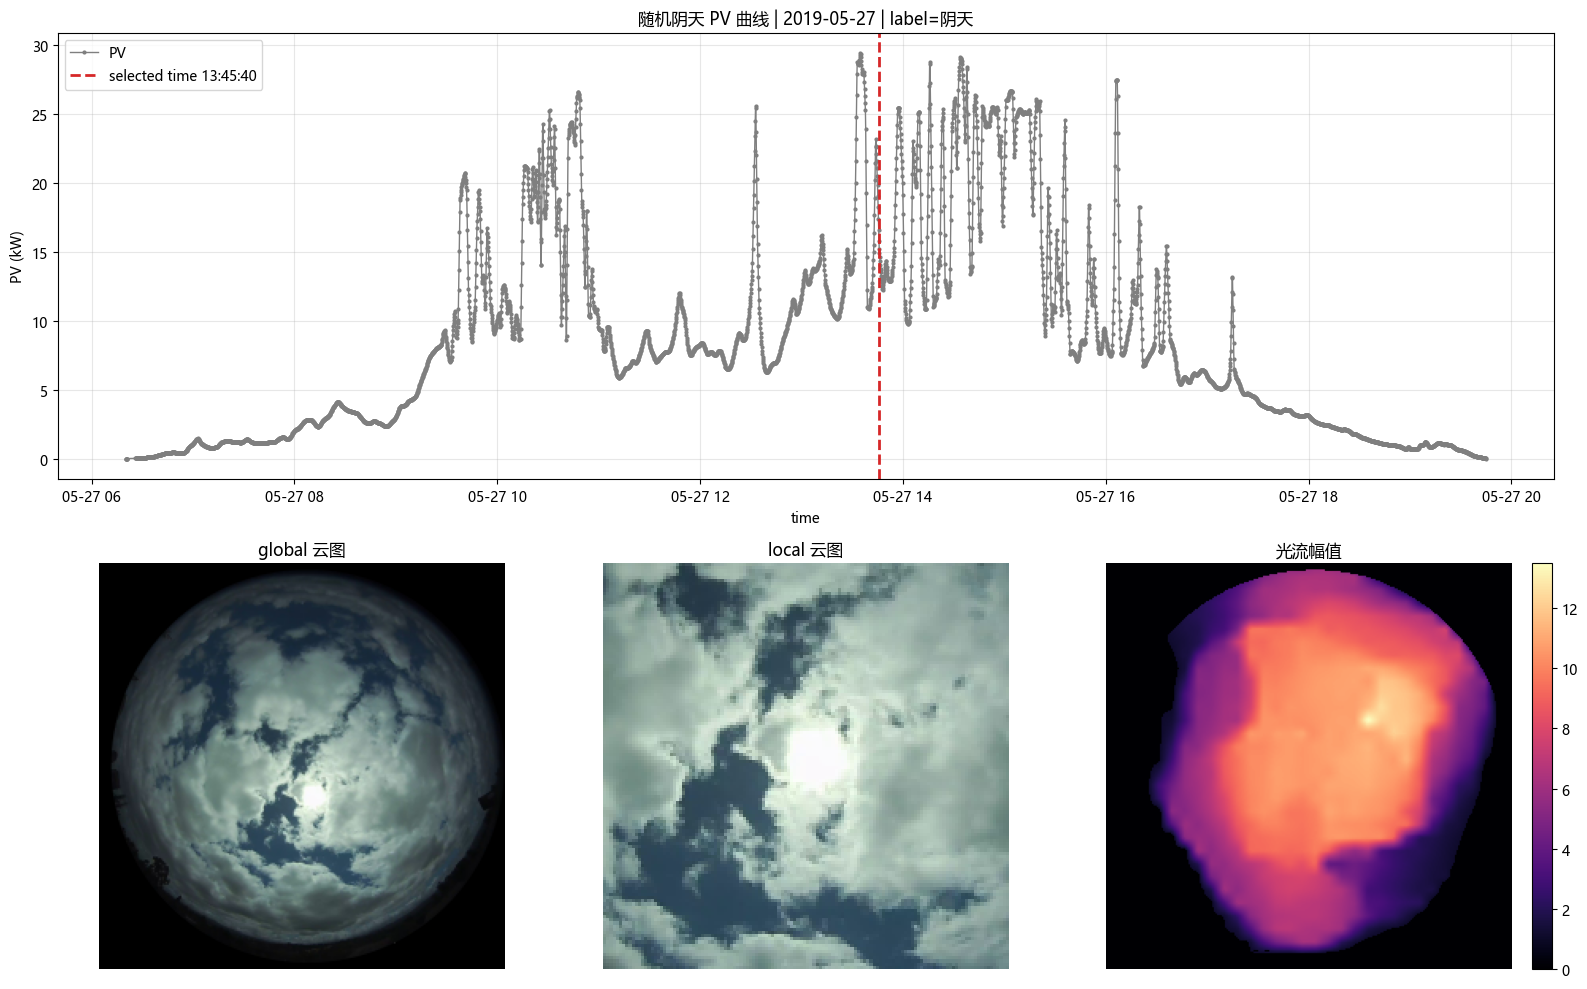

chosen_date = 2019-05-27
selected_time = 2019-05-27 13:45:40
frame idx = 10871
pv at selected_time = 16.606178611583335
sun_pos = [1064, 1193]
flow magnitude min/max/mean = 0.0 13.480381965637207 4.411014080047607


In [22]:
from pv_day_weather_classifier import load_pv_series, classify_all_days, extract_day_series

pv_series = load_pv_series(v3_dir.parent / 'pv_data' / 'pv_output_valid.pkl')
daily_df = classify_all_days(pv_series)
cloudy_days = daily_df[daily_df['label'] == '阴天'].copy()

if cloudy_days.empty:
    raise ValueError('没有找到阴天日期，请检查分类器阈值。')

rng = np.random.default_rng(7)
chosen_row = cloudy_days.iloc[rng.integers(0, len(cloudy_days))]
chosen_date = pd.Timestamp(chosen_row['date'])
day_series = extract_day_series(pv_series, chosen_date)

image_time_index = pd.DatetimeIndex(pd.to_datetime(all_times))
candidate_times = day_series.index.intersection(image_time_index)
candidate_times = candidate_times[day_series.loc[candidate_times] > 0]

if len(candidate_times) == 0:
    chosen_time = image_time_index[len(image_time_index) // 2]
else:
    chosen_time = pd.Timestamp(candidate_times[rng.integers(0, len(candidate_times))])

selected_time = pd.Timestamp(chosen_time)
frame_pos = image_time_index.get_indexer([selected_time])[0]
if frame_pos < 0:
    frame_pos = int(image_time_index.get_indexer([selected_time], method='nearest')[0])
idx = int(frame_pos)

with h5py.File(dual_h5, 'r') as dual_f, h5py.File(flow_h5, 'r') as flow_f:
    dual_grp = dual_f['trainval']
    flow_ds = flow_f['trainval']['global_flow_log']

    global_img = dual_grp['global_images_log'][idx].astype(np.uint8)
    local_img = dual_grp['local_images_log'][idx].astype(np.uint8)
    flow_frame = flow_ds[idx].astype(np.float32)
    flow_mag = np.sqrt(flow_frame[0] ** 2 + flow_frame[1] ** 2)
    sun_pos = dual_grp['sun_pos'][idx].tolist()

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, height_ratios=[1.1, 1.0])

ax0 = fig.add_subplot(gs[0, :])
ax0.plot(day_series.index, day_series.values, color='tab:gray', linewidth=1.0, marker='o', markersize=2, label='PV')
ax0.axvline(selected_time, color='tab:red', linestyle='--', linewidth=2, label=f'selected time {selected_time:%H:%M:%S}')
ax0.set_title(f'随机阴天 PV 曲线 | {chosen_date.date()} | label={chosen_row["label"]}')
ax0.set_xlabel('time')
ax0.set_ylabel('PV (kW)')
ax0.grid(True, alpha=0.3)
ax0.legend(loc='upper left')

ax1 = fig.add_subplot(gs[1, 0])
ax1.imshow(np.transpose(global_img, (1, 2, 0)))
ax1.set_title('global 云图')
ax1.axis('off')

ax2 = fig.add_subplot(gs[1, 1])
ax2.imshow(np.transpose(local_img, (1, 2, 0)))
ax2.set_title('local 云图')
ax2.axis('off')

ax3 = fig.add_subplot(gs[1, 2])
im = ax3.imshow(flow_mag, cmap='magma')
ax3.set_title('光流幅值')
ax3.axis('off')
fig.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print('chosen_date =', chosen_date.date())
print('selected_time =', selected_time)
print('frame idx =', idx)
print('pv at selected_time =', float(day_series.loc[selected_time]))
print('sun_pos =', sun_pos)
print('flow magnitude min/max/mean =', float(flow_mag.min()), float(flow_mag.max()), float(flow_mag.mean()))